# 6D-VHQ Analysis Notebook 7: Cross-Experiment Analysis


In [1]:
## libraries

import pandas as pd
from pathlib import Path
import os
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

In [2]:
### filepaths ###

project_path =  Path().resolve().parent 
tables_path = os.path.join(project_path, "tables_data")
qKeys_path = os.path.join(project_path, "question_keys")


## Import data from strobe and psychedelic experiments

In [3]:
df_vhq_lab_dims = pd.read_csv(os.path.join(tables_path, "df_vhq_lab_dims.csv"))
display(df_vhq_lab_dims)

df_vhq_rec_dims = pd.read_csv(os.path.join(tables_path, "df_vhq_rec_dims.csv"))
display(df_vhq_rec_dims)


,pcode,condition,seat,trial_order,geometric,semantic,detail,vividness,entropy,focality
0,vs_22,0,1,53BA74C6021,2.000000,1.000000,1.666667,5.000000,1.000000,4.333333
1,vs_22,1,1,53BA74C6021,2.333333,1.000000,1.000000,4.000000,1.333333,5.000000
2,vs_22,2,1,53BA74C6021,2.000000,1.000000,1.000000,5.000000,1.333333,5.000000
3,vs_22,3,1,53BA74C6021,4.000000,1.333333,2.333333,3.666667,3.333333,5.000000
4,vs_22,4,1,53BA74C6021,5.000000,2.000000,4.666667,5.000000,2.333333,1.000000
...,...,...,...,...,...,...,...,...,...,...
600,vz036,6,3,253C671BA04,4.666667,1.000000,2.000000,2.000000,2.000000,3.333333
601,vz036,7,3,253C671BA04,1.000000,1.333333,1.000000,2.666667,1.666667,1.000000
602,vz036,A,3,253C671BA04,4.333333,2.333333,4.000000,4.000000,3.666667,1.666667
603,vz036,B,3,253C671BA04,5.000000,1.000000,2.666667,3.666667,1.000000,2.666667


,ResponseId,geometric,semantic,detail,vividness,entropy,focality
0,R_2XhSm3rVuTDh2XT,1.333333,5.000000,5.000000,4.333333,1.666667,2.666667
1,R_82J66rTAKMAkEMO,1.666667,2.000000,3.333333,5.000000,1.666667,1.333333
2,R_80OjC1M5y1RxlPM,5.000000,4.333333,2.000000,4.333333,1.666667,3.000000
3,R_8rdBxiZHeShoPvf,5.000000,1.333333,3.333333,3.333333,3.000000,4.000000
4,R_2rH7YSrGIo4VOqn,5.000000,3.666667,5.000000,5.000000,2.333333,3.000000
...,...,...,...,...,...,...,...
196,R_7cTzDfiLPQ0wBC9,5.000000,2.333333,5.000000,5.000000,1.000000,1.000000
197,R_1levP6TzI6EFeP7,3.666667,3.666667,4.000000,4.333333,4.333333,1.333333
198,R_6QEuAAP3YqW0Th7,3.666667,2.666667,4.333333,4.000000,1.000000,2.666667
199,R_6rF4jrVpI9mVj9v,3.000000,3.000000,5.000000,5.000000,1.000000,3.666667


## How do VHs differ across context

In [5]:


dim_cols = ["geometric", "semantic", "detail", "vividness", "entropy", "focality"]

df_vhq_lab_dims = df_vhq_lab_dims.copy()
df_vhq_lab_dims["condition_num"] = pd.to_numeric(
    df_vhq_lab_dims["condition"], errors="coerce"
)

strobe_mask  = df_vhq_lab_dims["condition_num"].between(0, 6, inclusive="both")
control_mask = df_vhq_lab_dims["condition_num"] == 7

def welch_t(a, b):
    """Return t, p, df for Welch's t-test (independent samples)."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    t_stat, p_val = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")
    n1, n2 = len(a), len(b)
    s1, s2 = np.var(a, ddof=1), np.var(b, ddof=1)
    df = (s1 / n1 + s2 / n2) ** 2 / (
        (s1 ** 2) / ((n1 ** 2) * (n1 - 1)) +
        (s2 ** 2) / ((n2 ** 2) * (n2 - 1))
    )
    return t_stat, p_val, df

def cohen_d_independent(a, b):
    """
    Cohen's d for independent samples.
    Sign is aligned with the t-test: mean(a) - mean(b).
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    a = a[~np.isnan(a)]
    b = b[~np.isnan(b)]
    n1, n2 = len(a), len(b)
    if n1 < 2 or n2 < 2:
        return np.nan
    s1 = np.var(a, ddof=1)
    s2 = np.var(b, ddof=1)
    s_pooled = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    if s_pooled == 0:
        return np.nan
    d = (np.mean(a) - np.mean(b)) / s_pooled
    return d

def sig_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

def fmt_p_apa(p):
    """APA-style p formatting."""
    if np.isnan(p):
        return "n/a"
    if p < 0.001:
        return "< .001"
    return f"= {p:.3f}".replace("0.", "." if p < 1 else "0.")

rows = []

for dim in dim_cols:
    psy = df_vhq_rec_dims[dim].astype(float).dropna()
    strobe = df_vhq_lab_dims.loc[strobe_mask, dim].astype(float).dropna()
    control = df_vhq_lab_dims.loc[control_mask, dim].astype(float).dropna()

    if len(psy) == 0 or len(strobe) == 0 or len(control) == 0:
        print(f"Skipping {dim}: one or more groups are empty.")
        continue

    # 1) Strobe vs psychedelic (Welch t; cohen d based on pooled SD)
    t1, p1, df1 = welch_t(strobe, psy)
    mean1, mean2 = strobe.mean(), psy.mean()
    sd1, sd2 = strobe.std(ddof=1), psy.std(ddof=1)
    diff1 = mean2 - mean1
    d1 = cohen_d_independent(strobe, psy)

    rows.append({
        "test": "Strobe vs psychedelic",
        "dimension": dim,
        "group1": "strobe (0–6)",
        "group2": "psychedelic",
        "n_group1": len(strobe),
        "n_group2": len(psy),
        "mean_group1": mean1,
        "sd_group1": sd1,
        "mean_group2": mean2,
        "sd_group2": sd2,
        "mean_diff_g2_minus_g1": diff1,  # group2 − group1
        "t": t1,
        "df": df1,
        "p": p1,           # raw p (will be kept)
        "cohen_d": d1,     # effect size
        "sig": sig_stars(p1),
    })

    # 2) Hallucinations vs control
    halluc = pd.concat([strobe, psy], axis=0)
    t2, p2, df2 = welch_t(halluc, control)
    mean_h, mean_c = halluc.mean(), control.mean()
    sd_h, sd_c = halluc.std(ddof=1), control.std(ddof=1)
    diff2 = mean_c - mean_h
    d2 = cohen_d_independent(halluc, control)

    rows.append({
        "test": "Hallucinations vs control",
        "dimension": dim,
        "group1": "hallucinations (strobe+psy)",
        "group2": "control (7)",
        "n_group1": len(halluc),
        "n_group2": len(control),
        "mean_group1": mean_h,
        "sd_group1": sd_h,
        "mean_group2": mean_c,
        "sd_group2": sd_c,
        "mean_diff_g2_minus_g1": diff2,  # group2 − group1
        "t": t2,
        "df": df2,
        "p": p2,           # raw p (will be kept)
        "cohen_d": d2,     # effect size
        "sig": sig_stars(p2),
    })

ttest_results = pd.DataFrame(rows)

# -----------------------------
# NEW: Holm correction (two families of 6)
# -----------------------------
ttest_results["p_raw"] = ttest_results["p"].astype(float)

ttest_results["p_adj_holm"] = np.nan
for test_name, idx in ttest_results.groupby("test").groups.items():
    pvals = ttest_results.loc[idx, "p_raw"].values
    p_adj = multipletests(pvals, alpha=0.05, method="holm")[1]
    ttest_results.loc[idx, "p_adj_holm"] = p_adj

# Update significance stars to reflect adjusted p-values (for reporting/figures)
ttest_results["sig"] = ttest_results["p_adj_holm"].apply(sig_stars)

# For consistency, replace the "p" column with adjusted p-values for downstream APA printing blocks
# (raw p-values remain in p_raw, and adjusted are in p_adj_holm).
ttest_results["p"] = ttest_results["p_adj_holm"]

col_order = [
    "test", "dimension",
    "p_raw", "p_adj_holm", "p",
    "group1", "group2",
    "n_group1", "n_group2",
    "mean_group1", "sd_group1",
    "mean_group2", "sd_group2",
    "mean_diff_g2_minus_g1",
    "t", "df", "cohen_d", "sig"
]
ttest_results = ttest_results[col_order]

for c in [
    "mean_group1", "sd_group1",
    "mean_group2", "sd_group2",
    "mean_diff_g2_minus_g1",
    "t", "df", "p_raw", "p_adj_holm", "p", "cohen_d"
]:
    ttest_results[c] = ttest_results[c].astype(float).round(3)

print("\nSupplementary table (Welch t-tests; Holm correction within each contrast across 6 dimensions):\n")
print(ttest_results)

# APA-style printed output, now using Holm-adjusted p (stored in row["p"])
print("\nAPA-style t-test results (Holm-adjusted within each contrast):\n")
for _, row in ttest_results.iterrows():
    test = row["test"]
    dim = row["dimension"]
    g1 = row["group1"]
    g2 = row["group2"]
    df_ = row["df"]
    t_ = row["t"]
    p_ = row["p"]  # adjusted p
    d_ = row["cohen_d"]
    p_txt = fmt_p_apa(p_)
    m1, s1 = row["mean_group1"], row["sd_group1"]
    m2, s2 = row["mean_group2"], row["sd_group2"]

    if test == "Strobe vs psychedelic":
        print(
            f"{dim} – {test}: "
            f"t({df_:.2f}) = {t_:.2f}, p {p_txt}, d = {d_:.2f}, "
            f"M_strobe = {m1:.2f}, SD_strobe = {s1:.2f}; "
            f"M_psychedelic = {m2:.2f}, SD_psychedelic = {s2:.2f}."
        )
    else:
        print(
            f"{dim} – {test}: "
            f"t({df_:.2f}) = {t_:.2f}, p {p_txt}, d = {d_:.2f}, "
            f"M_hallucinations = {m1:.2f}, SD_hallucinations = {s1:.2f}; "
            f"M_control = {m2:.2f}, SD_control = {s2:.2f}."
        )

# ===============================================
# APA-style one-line blocks for direct paper use
# ===============================================

def apa_entry(dim, t_, df_, p_, d_):
    """Return 'geometric, t(113.74) = 27.61, p < .001, d = 1.23'."""
    p_txt = fmt_p_apa(p_)
    return f"{dim}, t({df_:.2f}) = {t_:.2f}, p {p_txt}, d = {d_:.2f}"

# ---- Block 1: Hallucinations vs control ----
block1_entries = []
for _, row in ttest_results[ttest_results["test"]=="Hallucinations vs control"].iterrows():
    entry = apa_entry(
        dim=row["dimension"],
        t_=row["t"],
        df_=row["df"],
        p_=row["p"],       
        d_=row["cohen_d"]
    )
    block1_entries.append(entry)

block1_text = "(" + "; ".join(block1_entries) + ")."

print("\n==============================")
print("Hallucinations vs control APA block (Holm-adjusted across 6 dims):")
print("==============================")
print(block1_text)

# ---- Block 2: Strobe vs psychedelic ----
block2_entries = []
for _, row in ttest_results[ttest_results["test"]=="Strobe vs psychedelic"].iterrows():
    entry = apa_entry(
        dim=row["dimension"],
        t_=row["t"],
        df_=row["df"],
        p_=row["p"],          # adjusted p
        d_=row["cohen_d"]
    )
    block2_entries.append(entry)

block2_text = "(" + "; ".join(block2_entries) + ")."

print("\n==============================")
print("Strobe vs psychedelic APA block (Holm-adjusted across 6 dims):")
print("==============================")
print(block2_text)

display(ttest_results)



Supplementary table (Welch t-tests; Holm correction within each contrast across 6 dimensions):

                         test  dimension  p_raw  p_adj_holm      p  \
0       Strobe vs psychedelic  geometric  0.000       0.000  0.000   
1   Hallucinations vs control  geometric  0.000       0.000  0.000   
2       Strobe vs psychedelic   semantic  0.000       0.000  0.000   
3   Hallucinations vs control   semantic  0.004       0.011  0.011   
4       Strobe vs psychedelic     detail  0.000       0.000  0.000   
5   Hallucinations vs control     detail  0.000       0.000  0.000   
6       Strobe vs psychedelic  vividness  0.019       0.019  0.019   
7   Hallucinations vs control  vividness  0.028       0.056  0.056   
8       Strobe vs psychedelic    entropy  0.000       0.000  0.000   
9   Hallucinations vs control    entropy  0.000       0.000  0.000   
10      Strobe vs psychedelic   focality  0.000       0.000  0.000   
11  Hallucinations vs control   focality  0.029       0.056  0.

,test,dimension,p_raw,p_adj_holm,p,group1,group2,n_group1,n_group2,mean_group1,sd_group1,mean_group2,sd_group2,mean_diff_g2_minus_g1,t,df,cohen_d,sig
0,Strobe vs psychedelic,geometric,0.000,0.000,0.000,strobe (0–6),psychedelic,385,201,3.729,1.304,4.164,1.180,0.435,-4.087,442.836,-0.345,***
1,Hallucinations vs control,geometric,0.000,0.000,0.000,hallucinations (strobe+psy),control (7),586,55,3.878,1.279,1.291,0.574,-2.587,27.613,113.742,2.095,***
2,Strobe vs psychedelic,semantic,0.000,0.000,0.000,strobe (0–6),psychedelic,385,201,1.522,0.893,2.703,1.225,1.181,-12.097,313.796,-1.159,***
3,Hallucinations vs control,semantic,0.004,0.011,0.011,hallucinations (strobe+psy),control (7),586,55,1.927,1.162,1.612,0.696,-0.315,2.988,85.410,0.279,*
4,Strobe vs psychedelic,detail,0.000,0.000,0.000,strobe (0–6),psychedelic,385,201,2.577,1.318,3.803,1.181,1.226,-11.456,446.438,-0.963,***
5,Hallucinations vs control,detail,0.000,0.000,0.000,hallucinations (strobe+psy),control (7),586,55,2.997,1.399,1.242,0.610,-1.755,17.454,117.787,1.300,***
6,Strobe vs psychedelic,vividness,0.019,0.019,0.019,strobe (0–6),psychedelic,385,201,3.882,1.065,4.096,1.034,0.214,-2.354,416.488,-0.203,*
7,Hallucinations vs control,vividness,0.028,0.056,0.056,hallucinations (strobe+psy),control (7),586,55,3.956,1.058,3.564,1.252,-0.392,2.248,61.462,0.364,ns
8,Strobe vs psychedelic,entropy,0.000,0.000,0.000,strobe (0–6),psychedelic,385,201,2.982,1.371,2.493,1.119,-0.489,4.642,482.299,0.379,***
9,Hallucinations vs control,entropy,0.000,0.000,0.000,hallucinations (strobe+psy),control (7),586,55,2.814,1.310,1.424,0.752,-1.390,12.090,88.465,1.092,***


In [ ]:
# ==========================================================
# Descriptive table: Mean (SD) by group × 6D-VHQ dimension
# ==========================================================

group_defs = {
    "psychedelic": df_vhq_rec_dims,
    "strobe (0–6)": df_vhq_lab_dims.loc[strobe_mask],
    "control (7)": df_vhq_lab_dims.loc[control_mask],
    "hallucinations (strobe+psy)": None,  # will be constructed per-dimension
}

desc_rows = []
for dim in dim_cols:
    # Build hallucinations vector for this dimension (strobe+psy)
    psy = df_vhq_rec_dims[dim].astype(float)
    strobe = df_vhq_lab_dims.loc[strobe_mask, dim].astype(float)
    control = df_vhq_lab_dims.loc[control_mask, dim].astype(float)
    halluc = pd.concat([strobe, psy], axis=0)

    series_map = {
        "psychedelic": psy,
        "strobe (0–6)": strobe,
        "control (7)": control,
        "hallucinations (strobe+psy)": halluc,
    }

    for group_name, s in series_map.items():
        s = pd.to_numeric(s, errors="coerce").dropna()
        desc_rows.append({
            "dimension": dim,
            "group": group_name,
            "n": int(s.shape[0]),
            "mean": float(s.mean()) if len(s) else np.nan,
            "sd": float(s.std(ddof=1)) if len(s) > 1 else np.nan,
        })

desc_long = pd.DataFrame(desc_rows)

# Wide table: one row per dimension, columns per group
desc_wide = (
    desc_long
    .assign(mean_sd=lambda d: d.apply(lambda r: f"{r['mean']:.2f} ({r['sd']:.2f})" if pd.notna(r["mean"]) else "n/a", axis=1))
    .pivot(index="dimension", columns="group", values="mean_sd")
)

# Also provide n per group (optional but useful)
n_wide = desc_long.pivot(index="dimension", columns="group", values="n").astype("Int64")

# Order groups consistently
group_order = ["psychedelic", "strobe (0–6)", "control (7)", "hallucinations (strobe+psy)"]
desc_wide = desc_wide.reindex(columns=group_order)
n_wide = n_wide.reindex(columns=group_order)


print("\nDescriptives: Mean (SD) by group × dimension\n")
display(desc_wide)



Descriptives: Mean (SD) by group × dimension



group,psychedelic,strobe (0–6),control (7),hallucinations (strobe+psy)
dimension,,,,
detail,3.80 (1.18),2.58 (1.32),1.24 (0.61),3.00 (1.40)
entropy,2.49 (1.12),2.98 (1.37),1.42 (0.75),2.81 (1.31)
focality,2.44 (1.10),2.90 (1.32),2.33 (1.31),2.74 (1.27)
geometric,4.16 (1.18),3.73 (1.30),1.29 (0.57),3.88 (1.28)
semantic,2.70 (1.22),1.52 (0.89),1.61 (0.70),1.93 (1.16)
vividness,4.10 (1.03),3.88 (1.07),3.56 (1.25),3.96 (1.06)


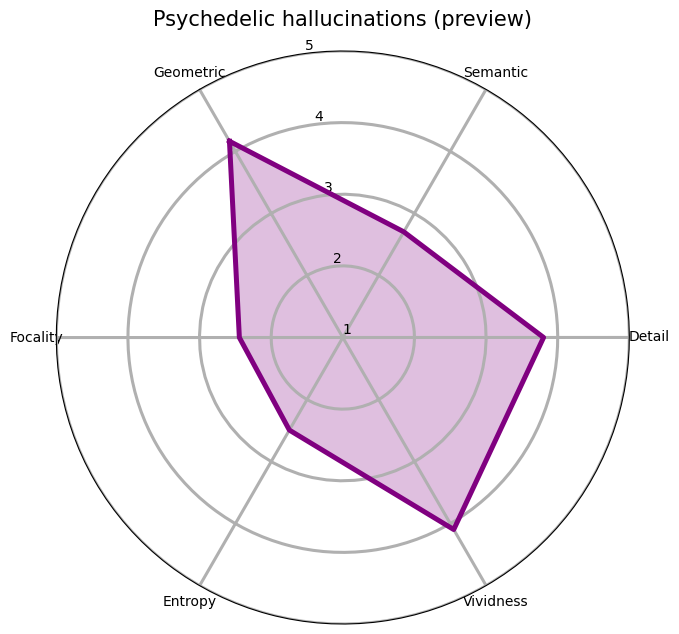

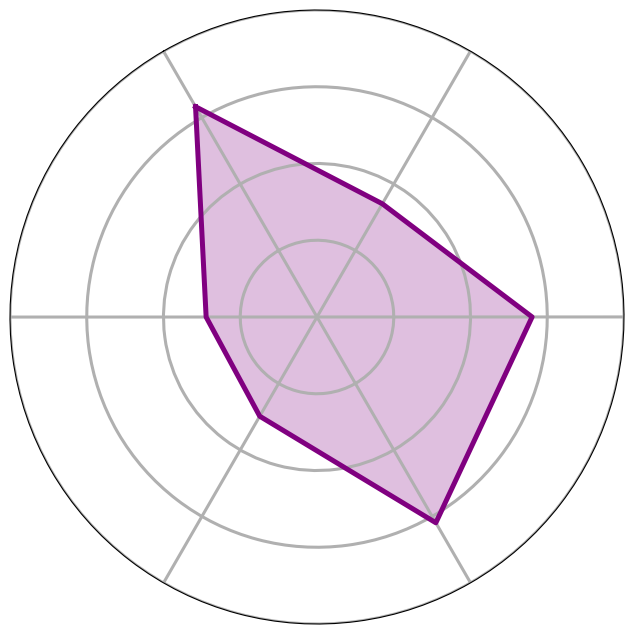

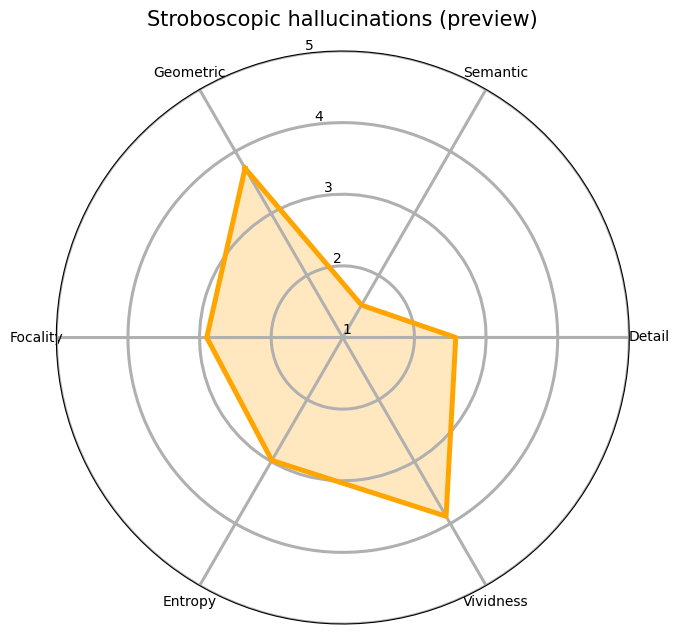

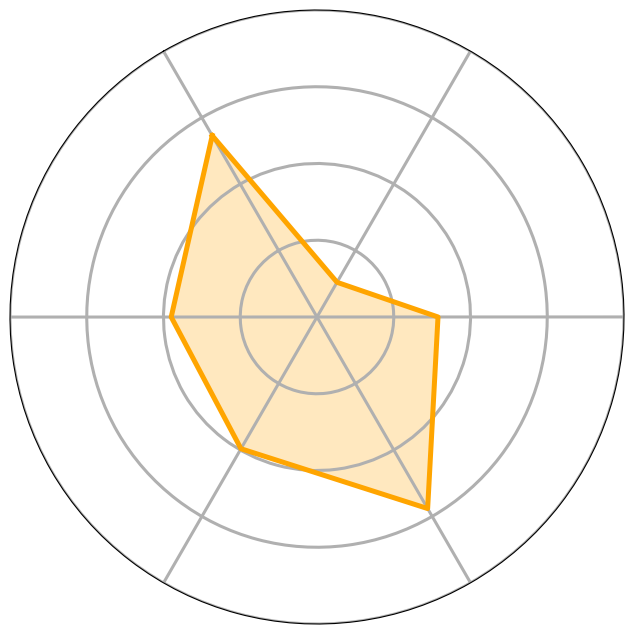

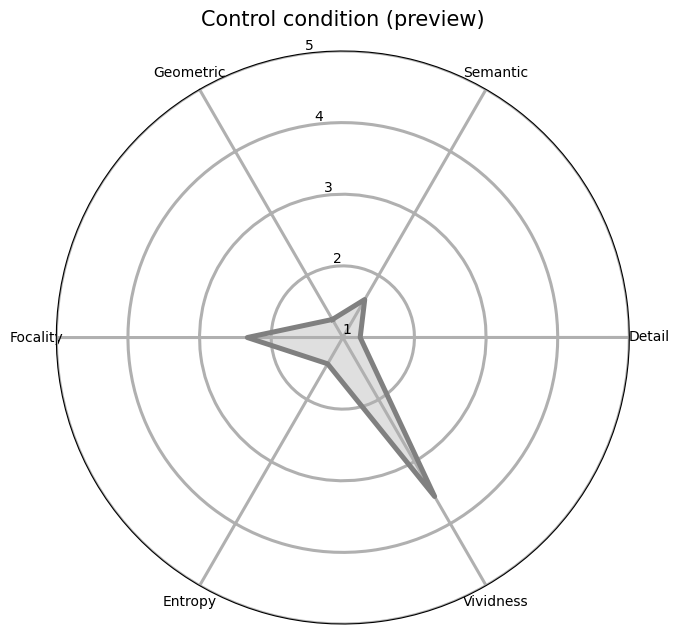

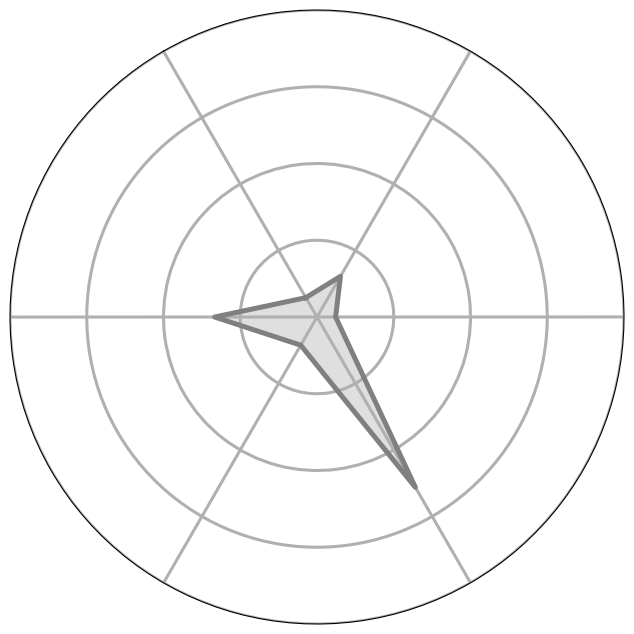

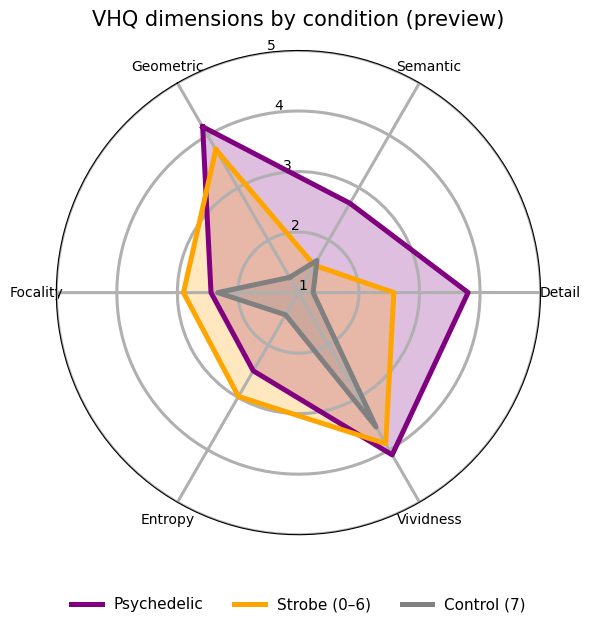

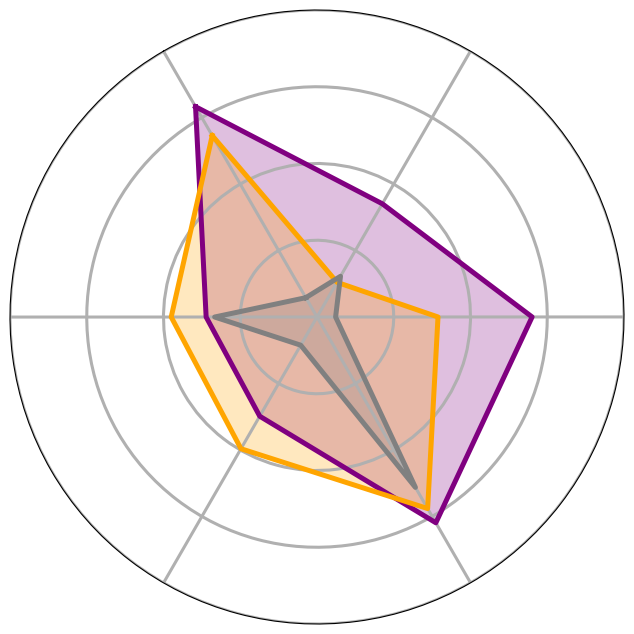

In [7]:


### globals

fig_width  = 12      # or your previous value
fig_height = 14      # or your previous value

spider_rot = np.deg2rad(30.01)   # your earlier rotation
lw_line    = 2                   # base linewidth multiplier
alpha_fill = 0.25                # transparency
text_size  = 14                  # legend text size baselin

# ============================================
# 1. Dimensions & angles
# ============================================
dims = ["geometric", "semantic", "detail", "vividness", "entropy", "focality"]
n_dims = len(dims)

angles = np.linspace(0, 2 * np.pi, n_dims, endpoint=False).tolist()
angles += angles[:1]  # close the loop

radial_ticks = [1, 2, 3, 4, 5]

# Colours for conditions
color_psy     = "purple"
color_strobe  = "orange"
color_control = "grey"

# ============================================
# 2. Mean profiles (pooled, trial-level)
# ============================================
psy_profile = df_vhq_rec_dims[dims].astype(float).mean().values

strobe_profile = (
    df_vhq_lab_dims
    .loc[strobe_mask, dims]
    .astype(float)
    .mean()
    .values
)

control_profile = (
    df_vhq_lab_dims
    .loc[control_mask, dims]
    .astype(float)
    .mean()
    .values
)

# ============================================
# 3. Generic radar helper with preview/real mode
# ============================================
def make_radar_figure_conditions(
    profiles,
    labels,
    colors,
    title="",
    show_dim_labels=False,
    show_radial_labels=False,
    show_legend=True,
    legend_ncol=1
):
    """
    profiles: list of 1D arrays/lists with length = n_dims
    labels:   list of legend labels (same length as profiles)
    colors:   list of colors (same length as profiles)
    """
    fig = plt.figure(figsize=(fig_width, fig_height / 2))
    ax  = fig.add_subplot(111, polar=True)

    # Rotation and direction
    ax.set_theta_offset(np.pi/2 + spider_rot)
    ax.set_theta_direction(-1)

    # Dimension labels
    if show_dim_labels:
        ax.set_thetagrids(
            np.degrees(angles[:-1]),
            labels=[d.capitalize() for d in dims]
        )
    else:
        ax.set_thetagrids(
            np.degrees(angles[:-1]),
            labels=[]
        )

    # Radial axis: 1–5
    ax.set_ylim(1, 5)
    ax.set_yticks(radial_ticks)
    if show_radial_labels:
        ax.set_yticklabels([str(t) for t in radial_ticks], fontsize=text_size-4)
    else:
        ax.set_yticklabels([])

    # Gridline thickness
    ax.grid(True)
    for gridline in ax.xaxis.get_gridlines():
        gridline.set_linewidth(2.2)
    for gridline in ax.yaxis.get_gridlines():
        gridline.set_linewidth(2.2)

    # Plot each profile
    for prof, lbl, col in zip(profiles, labels, colors):
        vals = prof.tolist() if hasattr(prof, "tolist") else list(prof)
        vals = vals + vals[:1]  # close the loop
        ax.plot(angles, vals, color=col, linewidth=lw_line * 1.8, label=lbl)
        ax.fill(angles, vals, color=col, alpha=alpha_fill)

    # Title
    ax.set_title(title, fontsize=text_size+1 if title else 0, pad=18)

    # Legend
    if show_legend:
        ax.legend(
            loc="upper center",
            bbox_to_anchor=(0.5, -0.1),
            ncol=legend_ncol,
            frameon=False,
            fontsize=text_size - 3
        )

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

    return fig, ax

# ============================================
# 4. Individual-condition plots
# ============================================

# 4a) Psychedelic only
fig_psy_preview, ax_psy_preview = make_radar_figure_conditions(
    profiles=[psy_profile],
    labels=["Psychedelic"],
    colors=[color_psy],
    title="Psychedelic hallucinations (preview)",
    show_dim_labels=True,
    show_radial_labels=True,
    show_legend=False
)

fig_psy_blank, ax_psy_blank = make_radar_figure_conditions(
    profiles=[psy_profile],
    labels=["Psychedelic"],
    colors=[color_psy],
    title="",
    show_dim_labels=False,
    show_radial_labels=False,
    show_legend=False
)

# 4b) Strobe only
fig_strobe_preview, ax_strobe_preview = make_radar_figure_conditions(
    profiles=[strobe_profile],
    labels=["Strobe (0–6)"],
    colors=[color_strobe],
    title="Stroboscopic hallucinations (preview)",
    show_dim_labels=True,
    show_radial_labels=True,
    show_legend=False
)

fig_strobe_blank, ax_strobe_blank = make_radar_figure_conditions(
    profiles=[strobe_profile],
    labels=["Strobe (0–6)"],
    colors=[color_strobe],
    title="",
    show_dim_labels=False,
    show_radial_labels=False,
    show_legend=False
)

# 4c) Control only
fig_control_preview, ax_control_preview = make_radar_figure_conditions(
    profiles=[control_profile],
    labels=["Control (constant light)"],
    colors=[color_control],
    title="Control condition (preview)",
    show_dim_labels=True,
    show_radial_labels=True,
    show_legend=False
)

fig_control_blank, ax_control_blank = make_radar_figure_conditions(
    profiles=[control_profile],
    labels=["Control (constant light)"],
    colors=[color_control],
    title="",
    show_dim_labels=False,
    show_radial_labels=False,
    show_legend=False
)

# ============================================
# 5. Combined plot: psychedelic vs strobe vs control
# ============================================

# Preview version (titles + labels + legend)
fig_all_preview, ax_all_preview = make_radar_figure_conditions(
    profiles=[psy_profile, strobe_profile, control_profile],
    labels=["Psychedelic", "Strobe (0–6)", "Control (7)"],
    colors=[color_psy, color_strobe, color_control],
    title="VHQ dimensions by condition (preview)",
    show_dim_labels=True,
    show_radial_labels=True,
    show_legend=True,
    legend_ncol=3
)

# Blank version (for final figure; you add labels manually)
fig_all_blank, ax_all_blank = make_radar_figure_conditions(
    profiles=[psy_profile, strobe_profile, control_profile],
    labels=["Psychedelic", "Strobe (0–6)", "Control (7)"],
    colors=[color_psy, color_strobe, color_control],
    title="",
    show_dim_labels=False,
    show_radial_labels=False,
    show_legend=False,
    legend_ncol=3
)
